In [1]:
from utils import LazyVideo
import fastplotlib as fpl
import numpy as np

fastplotlib version from git (0.4.0) and __version__ (0.5.0) don't match.


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),AMD Radeon RX 570 Series (RADV POLARIS10),DiscreteGPU,Vulkan,Mesa 22.3.6
✅,NVIDIA GeForce RTX 3080,DiscreteGPU,Vulkan,575.57.08
❗ limited,"llvmpipe (LLVM 15.0.6, 256 bits)",CPU,Vulkan,Mesa 22.3.6 (LLVM 15.0.6)
❌,"AMD Radeon RX 570 Series (polaris10, LLVM 15.0.6, DRM 3.49, 6.1.0-38-amd64)",Unknown,OpenGL,4.6 (Core Profile) Mesa 22.3.6


pygfx version from git (0.9.0) and __version__ (0.10.0) don't match.


Behavior:
- keypoints
- filtered kinematics (include pupil diameter)

Calcium: 
- vid of one plane
  - choose which vid(s) to show, raw, pmd, AC, bg, fluctuating bg
- z-slider
- also have grid viz showing all planes
- see what performance is like by drawing contours with line collection
- heatmap with cells grouped by how they respond
  - trial averaged activity
  - cell response patterns, early, on-stimulus, off-stimulus, late, etc.
- temporal plot with raw pixel values under the shown vids

Regression model using cells to best predict all or certain behavior parameters, such as left-right direction, pupil size, or all behavior

In [2]:
vid_l = LazyVideo("/home/kushal/amol_data/kushal_datashare/_iblrig_leftCamera.raw.mp4", as_grayscale=True)
vid_r = LazyVideo("/home/kushal/amol_data/kushal_datashare/_iblrig_rightCamera.raw.mp4", as_grayscale=True)

In [3]:
vid_l.shape

(639919, 1024, 1280)

In [4]:
vid_r.shape

(644673, 512, 640)

In [5]:
iw_l = fpl.ImageWidget(vid_l, histogram_widget=False, cmap="gray")

RFBOutputContext()

/home/kushal/repos/epic-neuro-viz/utils.py:315: UserWarning: min not implemented for LazyTiff, returning min of 0th index
  warn("min not implemented for LazyTiff, returning min of 0th index")
/home/kushal/repos/epic-neuro-viz/utils.py:320: UserWarning: max not implemented for LazyTiff, returning min of 0th index
  warn("max not implemented for LazyTiff, returning min of 0th index")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
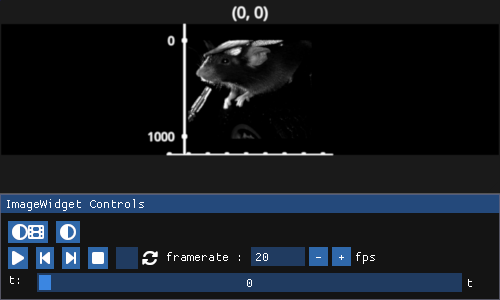

In [6]:
iw_l.show()

In [7]:
def get_frames():
    pass

def set_frames():
    pass

In [8]:
data_l = np.load("/home/kushal/amol_data/kushal_datashare/behavior_features_leftcam.npz", allow_pickle=True)

In [9]:
data_l["data"][()].keys()

dict_keys(['times', 'ROIMotionEnergy', 'dlc', 'features'])

In [10]:
timings = data_l["data"][()]["times"]
timings

array([   7.453 ,    7.48  ,    7.4865, ..., 4293.8605, 4293.8675,
       4293.874 ], shape=(639919,))

In [11]:
import math

In [12]:
def find_nearest_index(timepoints: np.ndarray, find_value: float):
    # find the index of the data closest to given timepoint    
    
    # get closest data index to the world space position of the selector
    idx = np.searchsorted(timepoints, find_value, side="left")

    # bisection algo is the fastest way to do this
    # math.fabs is faster than numpy abs for this usecase
    if idx > 0 and (
        idx == len(timepoints)
        or math.fabs(find_value - timepoints[idx - 1])
        < math.fabs(find_value - timepoints[idx])
    ):
        return round(idx - 1)
    else:
        return round(idx)

In [13]:
find_nearest_index(timings, 1654)

245810

In [14]:
timings[245810]

np.float64(1653.997)

In [15]:
data_l["data"][()]["features"]

,pupilDiameter_raw,pupilDiameter_smooth
0,NaN,14.499535
1,14.330261,14.499186
2,14.259375,14.498838
3,NaN,14.432856
4,NaN,14.366874
...,...,...
639914,13.254976,13.384882
639915,13.464370,13.463877
639916,13.703809,13.588650
639917,13.596510,13.763816


In [16]:
dlc = data_l["data"][()]["dlc"]

In [17]:
# every 3rd column is likelihood
lh_ixs = list(range(2, len(dlc.columns), 3))
point_ixs = [i for i in range(len(dlc.columns)) if i not in lh_ixs]

In [18]:
dlc.columns

Index(['nose_tip_x', 'nose_tip_y', 'nose_tip_likelihood', 'pupil_top_r_x',
       'pupil_top_r_y', 'pupil_top_r_likelihood', 'pupil_right_r_x',
       'pupil_right_r_y', 'pupil_right_r_likelihood', 'pupil_bottom_r_x',
       'pupil_bottom_r_y', 'pupil_bottom_r_likelihood', 'pupil_left_r_x',
       'pupil_left_r_y', 'pupil_left_r_likelihood', 'paw_l_x', 'paw_l_y',
       'paw_l_likelihood', 'paw_r_x', 'paw_r_y', 'paw_r_likelihood',
       'tube_top_x', 'tube_top_y', 'tube_top_likelihood', 'tube_bottom_x',
       'tube_bottom_y', 'tube_bottom_likelihood', 'tongue_end_l_x',
       'tongue_end_l_y', 'tongue_end_l_likelihood', 'tongue_end_r_x',
       'tongue_end_r_y', 'tongue_end_r_likelihood'],
      dtype='object')

In [19]:
lh_ixs

[2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32]

In [25]:
dlc.columns[lh_ixs]

Index(['nose_tip_likelihood', 'pupil_top_r_likelihood',
       'pupil_right_r_likelihood', 'pupil_bottom_r_likelihood',
       'pupil_left_r_likelihood', 'paw_l_likelihood', 'paw_r_likelihood',
       'tube_top_likelihood', 'tube_bottom_likelihood',
       'tongue_end_l_likelihood', 'tongue_end_r_likelihood'],
      dtype='object')

In [20]:
lh_cols = dlc.columns[lh_ixs]

In [21]:
x_cols = dlc.columns[point_ixs][::2]
y_cols = dlc.columns[point_ixs][1::2]

In [22]:
index = 0
points = np.column_stack([dlc[x_cols].iloc[index].to_numpy(), dlc[y_cols].iloc[index].to_numpy()])
alpha = dlc[lh_cols].iloc[index].to_numpy()

In [23]:
alpha

array([1.00000000e+00, 9.53123331e-01, 8.67343426e-01, 1.51592404e-01,
       7.42370069e-01, 9.98105884e-01, 9.99248803e-01, 9.99686241e-01,
       9.99893188e-01, 5.18417546e-05, 5.58843931e-05])

In [123]:
scatter = iw_l.figure[0, 0].add_scatter(points, cmap="tab20", sizes=10)
scatter.colors[:, -1] = alpha

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


In [124]:
def update_index(index):
    t = index["t"]
    scatter.data[:, :-1] = np.column_stack([dlc[x_cols].iloc[t].to_numpy(), dlc[y_cols].iloc[t].to_numpy()])
    scatter.colors[:, -1] = dlc[lh_cols].iloc[t].to_numpy()

iw_l.add_event_handler(update_index)

In [2]:
import numpy as np

In [12]:
ops = np.load("/home/kushal/amol_data/SP044/2023-06-27/001/alf/FOV_07/_suite2p_ROIData.raw.zip", allow_pickle=True)["ops"][()]

In [20]:
shape = ops['nframes'], ops['Ly'], ops['Lx']

In [14]:
np.load("/home/kushal/amol_data/SP044/2023-06-27/001/alf/FOV_07/mpci.times.npy")

array([1.17897907e+00, 1.32497907e+00, 1.47147907e+00, ...,
       4.16191048e+03, 4.16205648e+03, 4.16220248e+03], shape=(27170,))

In [21]:
movie = np.memmap(
    "/home/kushal/amol_data/SP044/2023-06-27/001/suite2p/plane7/imaging.frames_motionRegistered.bin",
    dtype=np.int16,
    mode="r",
    shape=shape,
)

In [22]:
movie.shape

(13585, 512, 512)

RFBOutputContext()

/home/kushal/repos/fastplotlib/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
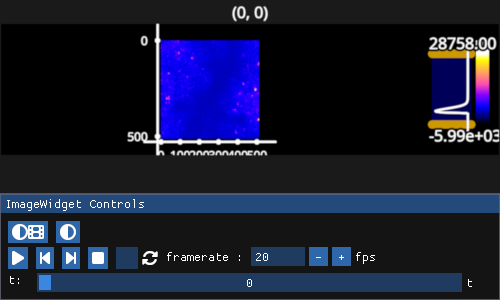

In [26]:
iw_c = fpl.ImageWidget(movie, cmap="gnuplot2")
iw_c.show()